In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Most Runs - 2008.csv",header=None,usecols=[2,5,7])
df.columns = ['Mat','Runs','Avg']


In [ ]:
df.head()

,Mat,Runs,Avg
0,Mat,Runs,Avg
1,11,616,68.44
2,14,534,41.07
3,14,518,43.16
4,15,472,47.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Mat     151 non-null    object
 1   Runs    151 non-null    object
 2   Avg     151 non-null    object
dtypes: object(3)
memory usage: 3.7+ KB


In [ ]:
df.describe()

,Mat,Runs,Avg
count,151,151,151
unique,17,105,105
top,13,2,0
freq,15,9,12


In [ ]:
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')
df['Mat'] = pd.to_numeric(df['Mat'], errors='coerce')
df['Avg'] = pd.to_numeric(df['Avg'], errors='coerce')

,Mat,Runs,Avg
43,5.0,152.0,152.0


<Axes: xlabel='Runs', ylabel='Density'>

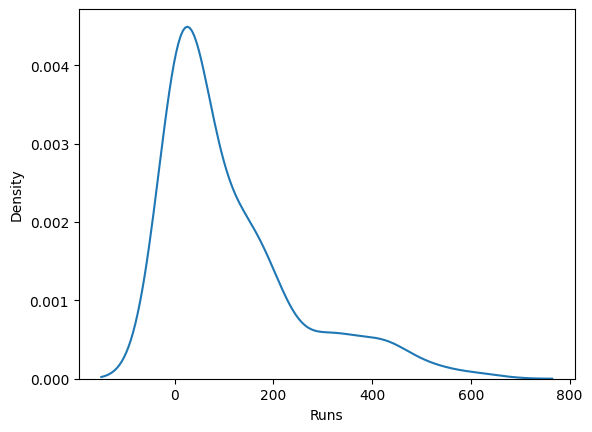

In [ ]:
sns.kdeplot(df['Runs'])

<Axes: xlabel='Runs', ylabel='Mat'>

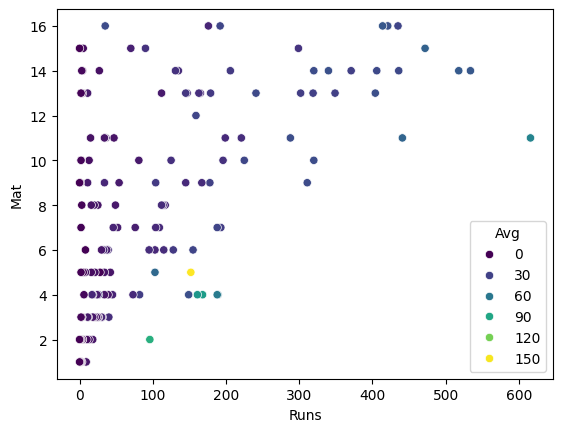

In [ ]:
sns.scatterplot(x=df['Runs'], y=df['Mat'], hue=df['Avg'], palette='viridis')

<Axes: xlabel='Runs', ylabel='Mat'>

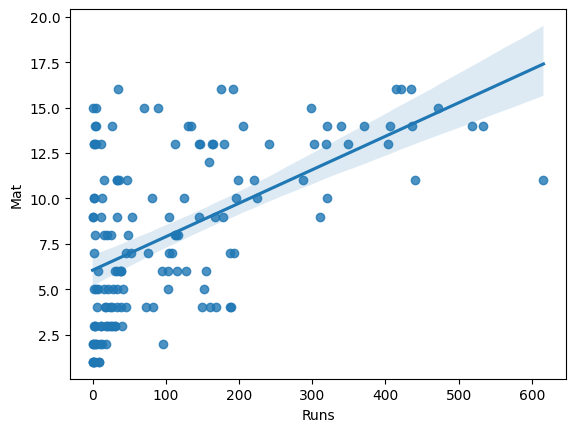

In [ ]:
sns.regplot(x=df['Runs'], y=df['Mat'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop('Avg',axis = 1),
                                                 df['Avg'],
                                                 test_size = 0.3,
                                                 random_state = 0)

X_train.shape,X_test.shape

((105, 2), (46, 2))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

In [ ]:
print(np.round(X_train.describe(),1))

         Mat   Runs
count  104.0  104.0
mean     7.9  107.2
std      4.7  137.0
min      1.0    0.0
25%      4.0    9.8
50%      7.5   38.0
75%     13.0  163.5
max     16.0  616.0


In [ ]:
print(np.round(X_train_scaled.describe(),1))

         Mat   Runs
count  104.0  104.0
mean     0.5    0.2
std      0.3    0.2
min      0.0    0.0
25%      0.2    0.0
50%      0.4    0.1
75%      0.8    0.3
max      1.0    1.0


Text(0.5, 1.0, 'After Scaling')

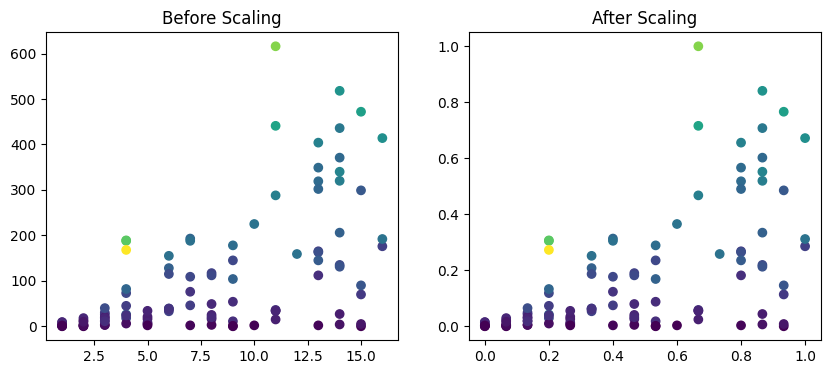

In [ ]:
fig,(no1,no2) = mt.subplots(nrows = 1,ncols = 2,figsize = (10,4))

no1.scatter(X_train['Mat'],X_train['Runs'],c = y_train)
no1.set_title('Before Scaling')

no2.scatter(X_train_scaled['Mat'],X_train_scaled['Runs'],c = y_train)
no2.set_title('After Scaling')

<Axes: title={'center': 'After Scaling'}, xlabel='Mat', ylabel='Density'>

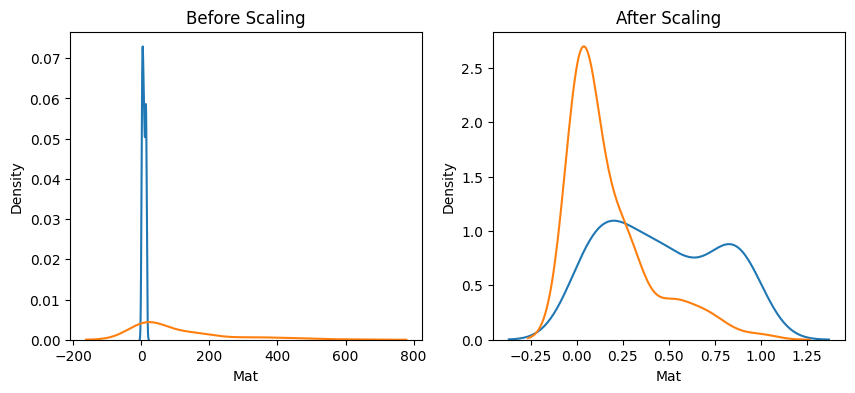

In [ ]:
fig,(no1,no2) = mt.subplots(nrows = 1,ncols = 2,figsize = (10,4))

no1.set_title('Before Scaling')
sns.kdeplot(X_train['Mat'],ax = no1)
sns.kdeplot(X_train['Runs'],ax = no1)

no2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Mat'],ax = no2)
sns.kdeplot(X_train_scaled['Runs'],ax = no2)

<Axes: title={'center': 'After Scaling'}, xlabel='Mat', ylabel='Density'>

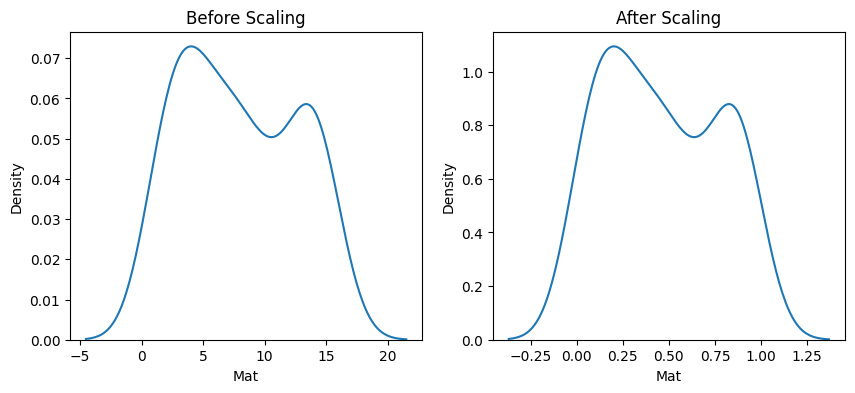

In [ ]:
fig,(no1,no2) = mt.subplots(nrows = 1,ncols = 2,figsize = (10,4))

no1.set_title('Before Scaling')
sns.kdeplot(X_train['Mat'],ax = no1)


no2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Mat'],ax = no2)
